In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from imblearn.metrics import geometric_mean_score
from sklearn.metrics import matthews_corrcoef, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [2]:
# 1. GENERAR UN DATASET "DIFÍCIL" (Mayor superposición, más ruido, fuerte desbalance)
X_gen, y_gen = make_classification(
    n_samples=2000, 
    n_features=10, 
    n_informative=6, 
    n_redundant=2,
    n_clusters_per_class=2,
    weights=[0.85, 0.15], # Desbalance 85% a 15%
    class_sep=0.6,        # Clases más mezcladas
    flip_y=0.05,          # 5% de ruido natural
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X_gen, y_gen, test_size=0.3, stratify=y_gen, random_state=42)

clases, conteos = np.unique(y_train, return_counts=True)
ratio_original = conteos[1] / conteos[0]

In [3]:
def calcular_gps(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        tnr = tn / (tn + fp) if (tn + fp) > 0 else 0
        if tpr + tnr == 0:
            return 0.0
        return 2 * (tpr * tnr) / (tpr + tnr)
    return 0.0

def evaluar_rendimiento_predictivo(X_tr, y_tr):
    rf = RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    y_pred = rf.predict(X_test)
    return geometric_mean_score(y_test, y_pred), matthews_corrcoef(y_test, y_pred), calcular_gps(y_test, y_pred)

In [4]:
samplers_dict = {'SMOTE': SMOTE, 'ADASYN': ADASYN, 'ROS': RandomOverSampler}
ratios_a_probar = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0] # Incluimos más pasos
resultados_totales = []

gmean_orig, mcc_orig, gps_orig = evaluar_rendimiento_predictivo(X_train, y_train)

print(f"Ratio Original del Dataset Complejo: {ratio_original:.3f}")
print("Iniciando escaneo predictivo...")

for nombre_sampler, SamplerClass in samplers_dict.items():
    # Añadir baseline
    resultados_totales.append({
        'Sampler': nombre_sampler, 'Ratio': round(ratio_original, 3),
        'G-mean': gmean_orig, 'MCC': mcc_orig, 'GPS': gps_orig
    })
    
    for r in ratios_a_probar:
        if r <= ratio_original: continue # Saltar ratios menores al original
        try:
            sampler = SamplerClass(sampling_strategy=r, random_state=42)
            X_res, y_res = sampler.fit_resample(X_train, y_train)
            g, m, gp = evaluar_rendimiento_predictivo(X_res, y_res)
            resultados_totales.append({
                'Sampler': nombre_sampler, 'Ratio': r,
                'G-mean': g, 'MCC': m, 'GPS': gp
            })
        except:
            pass

df_todos_resultados = pd.DataFrame(resultados_totales)

Ratio Original del Dataset Complejo: 0.202
Iniciando escaneo predictivo...


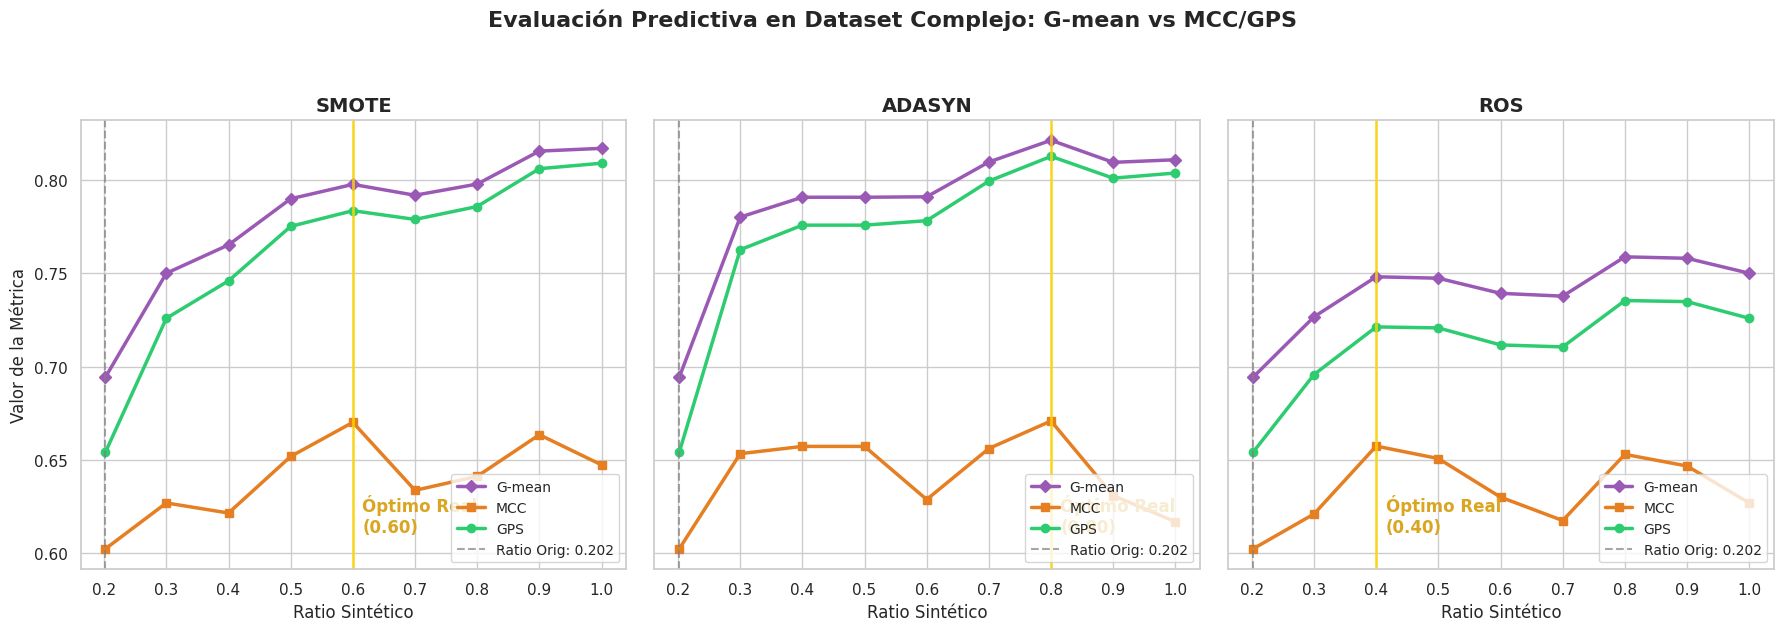

In [5]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, nombre in enumerate(['SMOTE', 'ADASYN', 'ROS']):
    ax = axes[i]
    df_sub = df_todos_resultados[df_todos_resultados['Sampler'] == nombre].reset_index(drop=True)
    
    ax.plot(df_sub['Ratio'], df_sub['G-mean'], marker='D', color='#9b59b6', linewidth=2.5, label='G-mean')
    ax.plot(df_sub['Ratio'], df_sub['MCC'], marker='s', color='#e67e22', linewidth=2.5, label='MCC')
    ax.plot(df_sub['Ratio'], df_sub['GPS'], marker='o', color='#2ecc71', linewidth=2.5, label='GPS')
    
    ax.axvline(x=ratio_original, color='gray', linestyle='--', alpha=0.7, label=f'Ratio Orig: {ratio_original:.3f}')
    
    mejor_idx = df_sub['MCC'].idxmax()
    mejor_ratio_mcc = df_sub.loc[mejor_idx, 'Ratio']
    ax.axvline(x=mejor_ratio_mcc, color='gold', linestyle='-', linewidth=2, alpha=0.8)
    ax.text(mejor_ratio_mcc + 0.015, ax.get_ylim()[0] + 0.02, f'Óptimo Real\n({mejor_ratio_mcc:.2f})', color='goldenrod', fontweight='bold')
    
    ax.set_title(f'{nombre}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Ratio Sintético', fontsize=12)
    if i == 0: ax.set_ylabel('Valor de la Métrica', fontsize=12)
    ax.legend(loc='lower right', fontsize=10)

plt.suptitle('Evaluación Predictiva en Dataset Complejo: G-mean vs MCC/GPS', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

In [6]:
resumen = []
baseline = df_todos_resultados[df_todos_resultados['Ratio'] == round(ratio_original, 3)].iloc[0]
resumen.append({'Método': 'Baseline (Sin Muestreo)', 'Ratio Óptimo': baseline['Ratio'], 'MCC Máximo': baseline['MCC'], 'GPS': baseline['GPS'], 'G-mean': baseline['G-mean']})

for nombre in ['SMOTE', 'ADASYN', 'ROS']:
    df_sub = df_todos_resultados[df_todos_resultados['Sampler'] == nombre]
    mejor_idx = df_sub['MCC'].idxmax()
    fila_optima = df_sub.loc[mejor_idx]
    resumen.append({'Método': nombre, 'Ratio Óptimo': fila_optima['Ratio'], 'MCC Máximo': fila_optima['MCC'], 'GPS': fila_optima['GPS'], 'G-mean': fila_optima['G-mean']})

df_resumen = pd.DataFrame(resumen)
formato_tabla = df_resumen.style.highlight_max(subset=['MCC Máximo', 'GPS', 'G-mean'], color='lightgreen', axis=0).format({
    'Ratio Óptimo': '{:.3f}', 'MCC Máximo': '{:.4f}', 'GPS': '{:.4f}', 'G-mean': '{:.4f}'
}).set_properties(**{'text-align': 'center'})

display(formato_tabla)

,Método,Ratio Óptimo,MCC Máximo,GPS,G-mean
0,Baseline (Sin Muestreo),0.202,0.6025,0.6542,0.6944
1,SMOTE,0.600,0.6702,0.7835,0.7976
2,ADASYN,0.800,0.6709,0.8127,0.8213
3,ROS,0.400,0.6575,0.7213,0.7482
